In [32]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Load Titanic Dataset

df = pd.read_csv("../data/titanic.csv")

In [34]:
# Display first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
# Number of rows and columns

print(df.shape)

(891, 12)


In [36]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [38]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [39]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df = df.drop_duplicates()

In [42]:
df.to_csv("../cleaned_data/cleaned_titanic.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [43]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [44]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

In [45]:
# Fill missing Embarked values with the most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [46]:
# Drop Cabin because it has too many missing values
df.drop("Cabin", axis=1, inplace=True)

In [47]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [48]:
df.to_csv("../cleaned_data/cleaned_titanic.csv", index=False)

print("Data cleaned successfully!")

Data cleaned successfully!


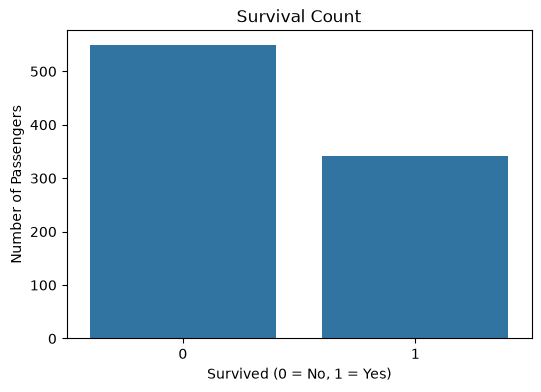

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

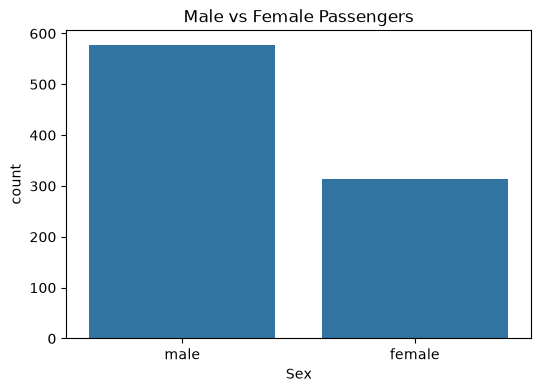

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)

plt.title("Male vs Female Passengers")

plt.show()

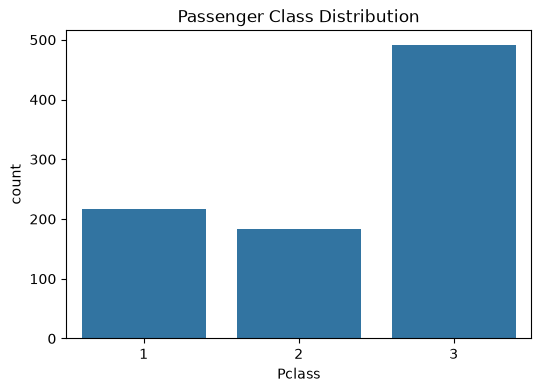

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")

plt.show()

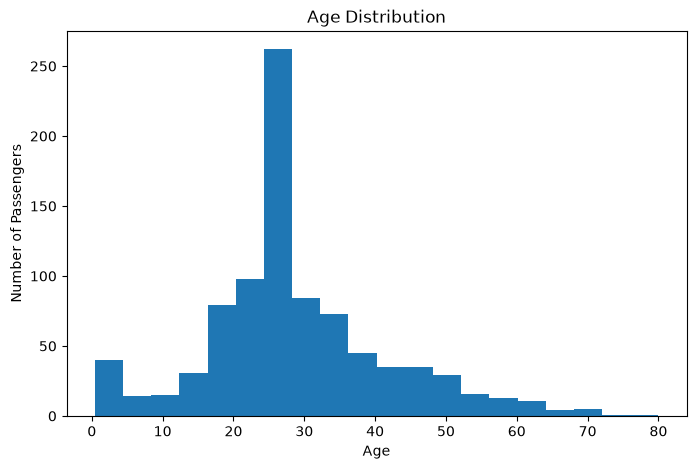

In [52]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

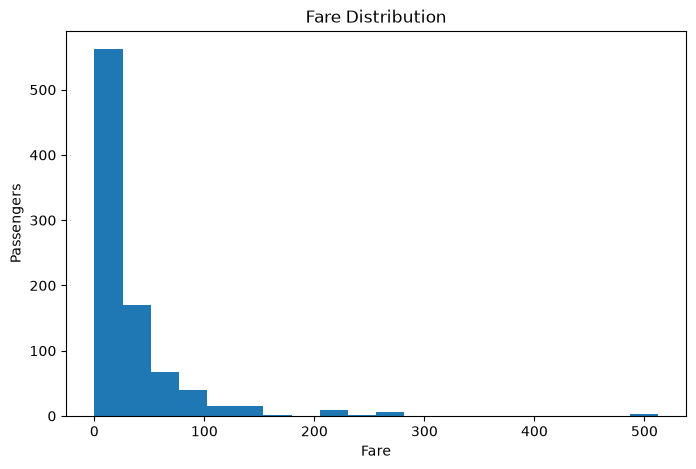

In [53]:
plt.figure(figsize=(8,5))

plt.hist(df["Fare"], bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passengers")

plt.show()

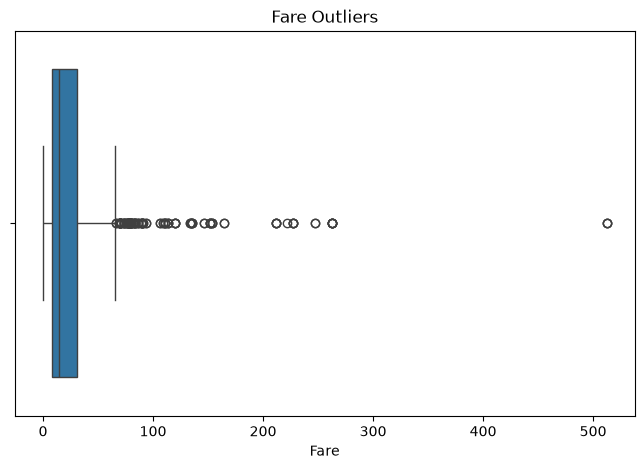

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.show()

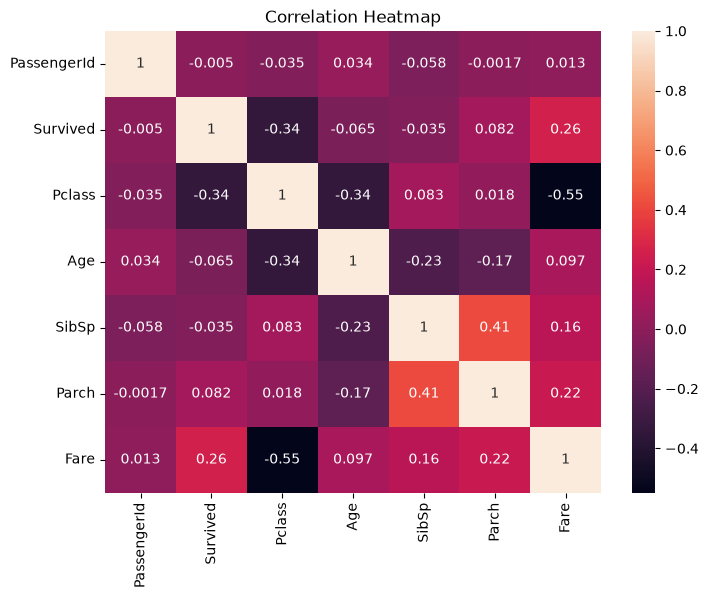

In [55]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

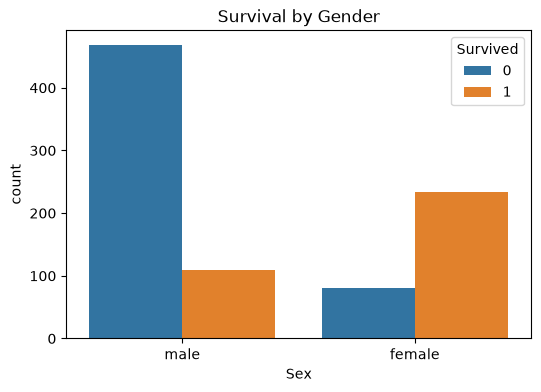

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.show()

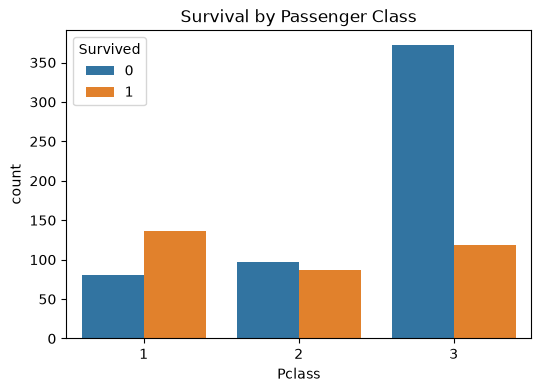

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()

In [58]:
plt.savefig("../images/survival_count.png")

<Figure size 640x480 with 0 Axes>

In [59]:
plt.savefig("../images/survival_count.png")
plt.show()

<Figure size 640x480 with 0 Axes>

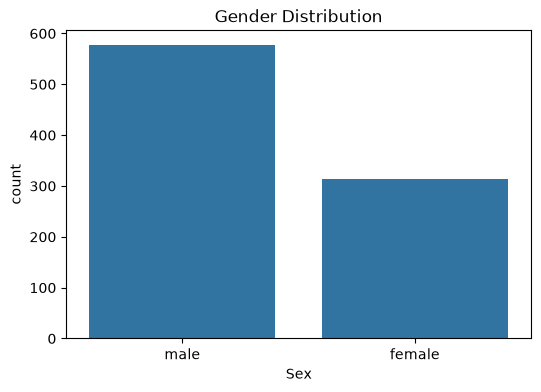

In [60]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.savefig("../images/gender_distribution.png")

plt.show()

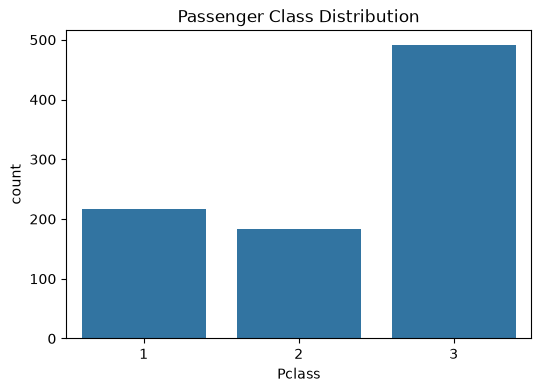

In [61]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")

plt.savefig("../images/passenger_class.png")

plt.show()

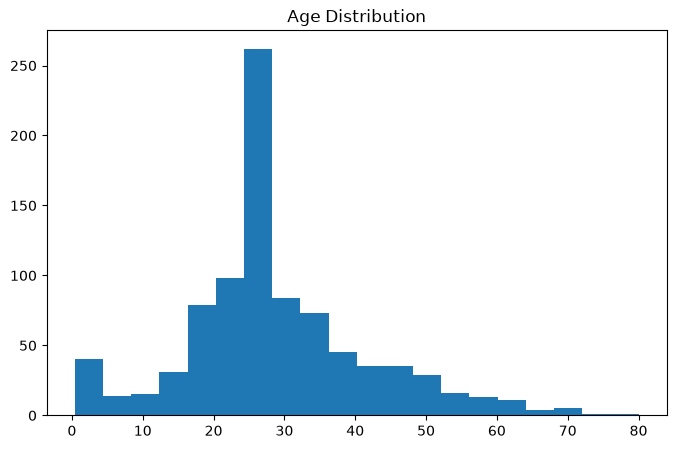

In [62]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")

plt.savefig("../images/age_distribution.png")

plt.show()

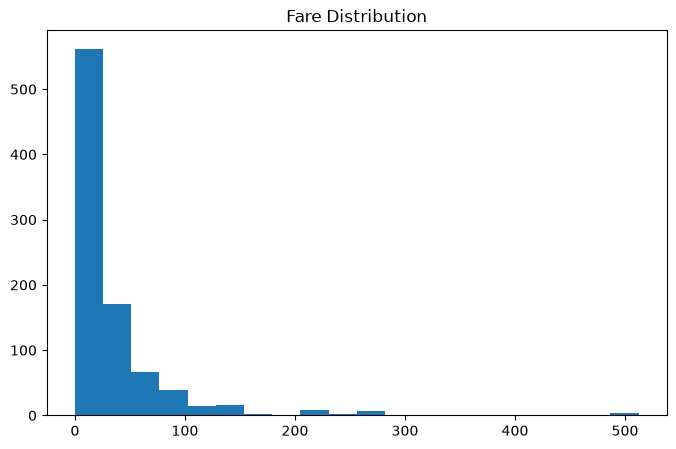

In [63]:
plt.figure(figsize=(8,5))

plt.hist(df["Fare"], bins=20)

plt.title("Fare Distribution")

plt.savefig("../images/fare_distribution.png")

plt.show()

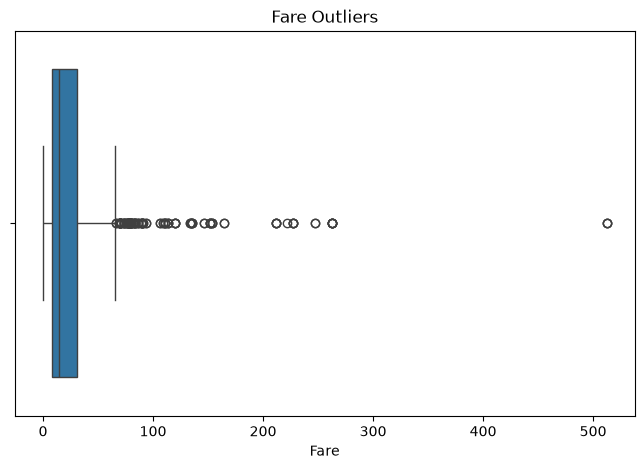

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.savefig("../images/fare_boxplot.png")

plt.show()

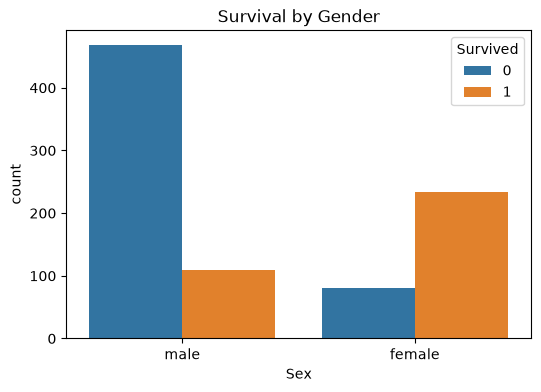

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")

plt.savefig("../images/survival_gender.png")

plt.show()

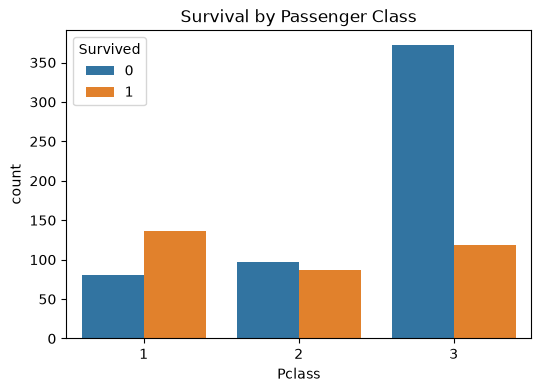

In [66]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.savefig("../images/survival_class.png")

plt.show()

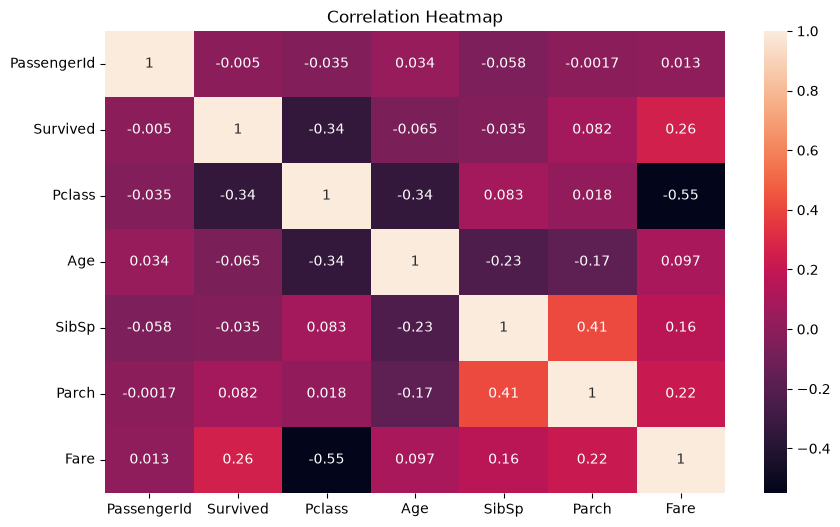

In [67]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.savefig("../images/heatmap.png")

plt.show()

In [68]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(891, 11)


In [69]:
print("Columns:")

for column in df.columns:
    print(column)

Columns:
PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Embarked


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.0 KB


In [71]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [72]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [73]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


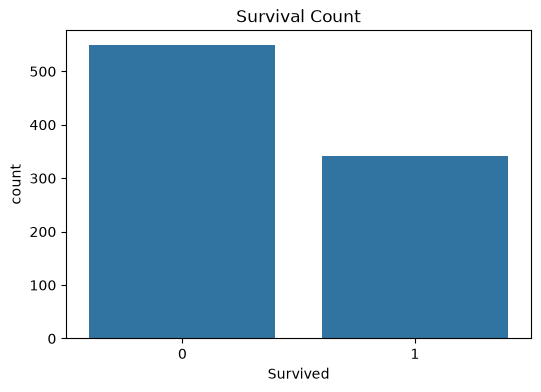

In [74]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived",data=df)

plt.title("Survival Count")

plt.savefig("../images/survival_count.png")

plt.show()

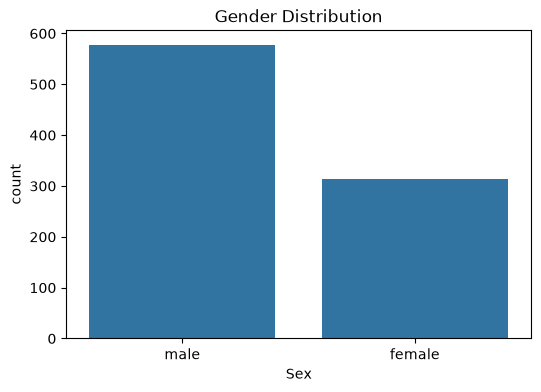

In [75]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex",data=df)

plt.title("Gender Distribution")

plt.savefig("../images/gender_distribution.png")

plt.show()

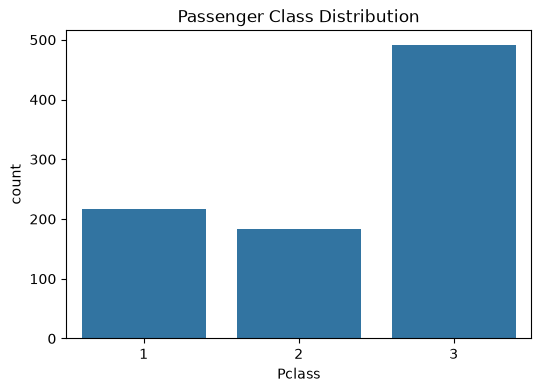

In [76]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass",data=df)

plt.title("Passenger Class Distribution")

plt.savefig("../images/passenger_class.png")

plt.show()

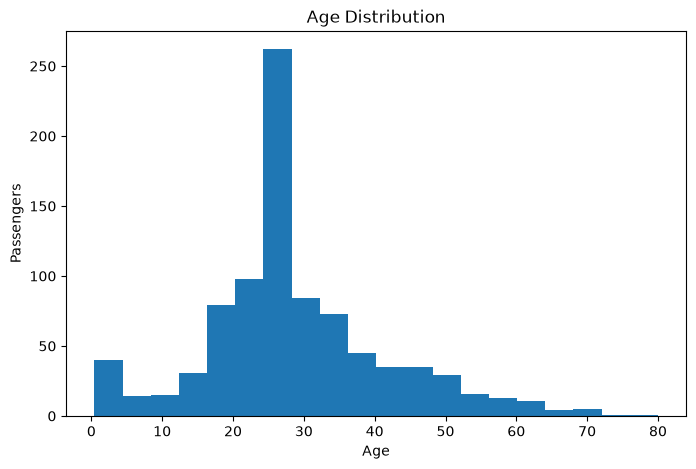

In [77]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"],bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Passengers")

plt.savefig("../images/age_distribution.png")

plt.show()

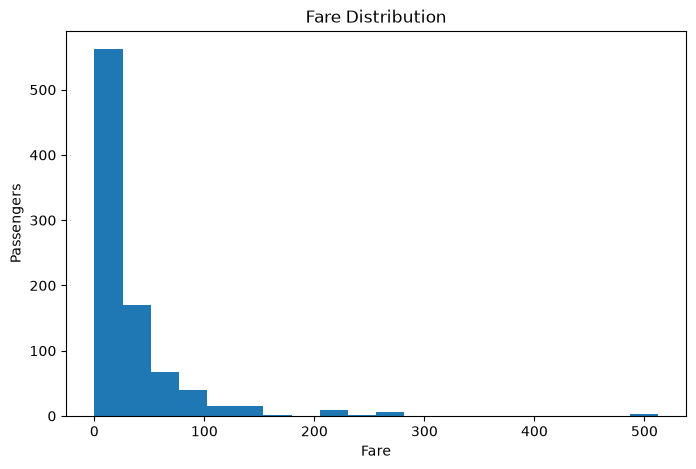

In [78]:
plt.figure(figsize=(8,5))

plt.hist(df["Fare"],bins=20)

plt.title("Fare Distribution")

plt.xlabel("Fare")

plt.ylabel("Passengers")

plt.savefig("../images/fare_distribution.png")

plt.show()

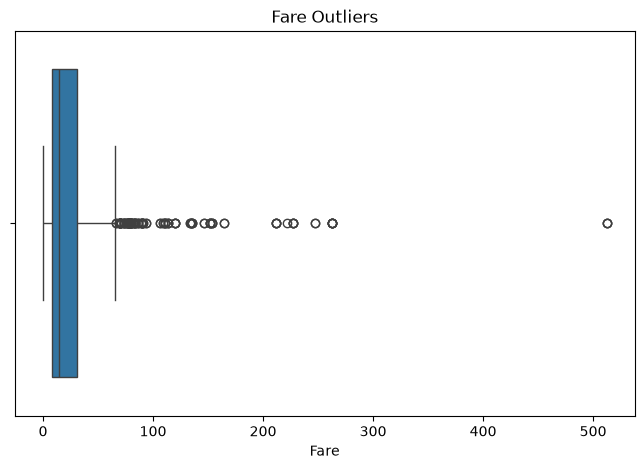

In [79]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.savefig("../images/fare_boxplot.png")

plt.show()

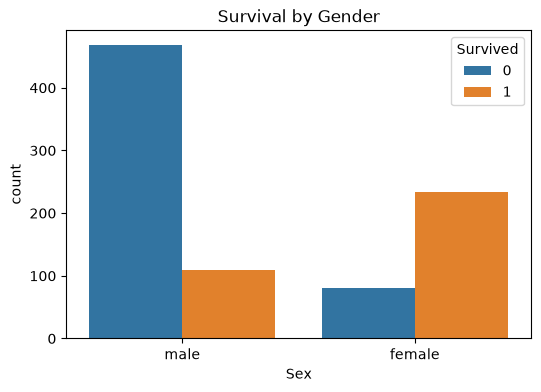

In [80]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex",hue="Survived",data=df)

plt.title("Survival by Gender")

plt.savefig("../images/survival_gender.png")

plt.show()

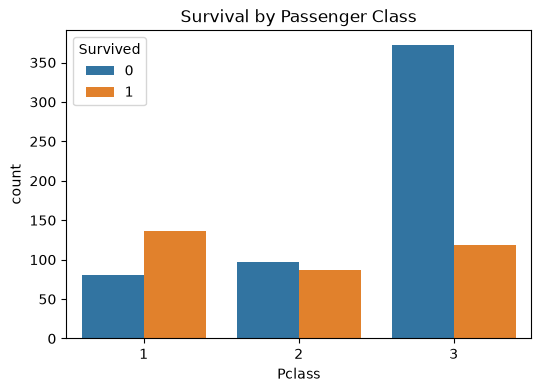

In [81]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass",hue="Survived",data=df)

plt.title("Survival by Passenger Class")

plt.savefig("../images/survival_class.png")

plt.show()

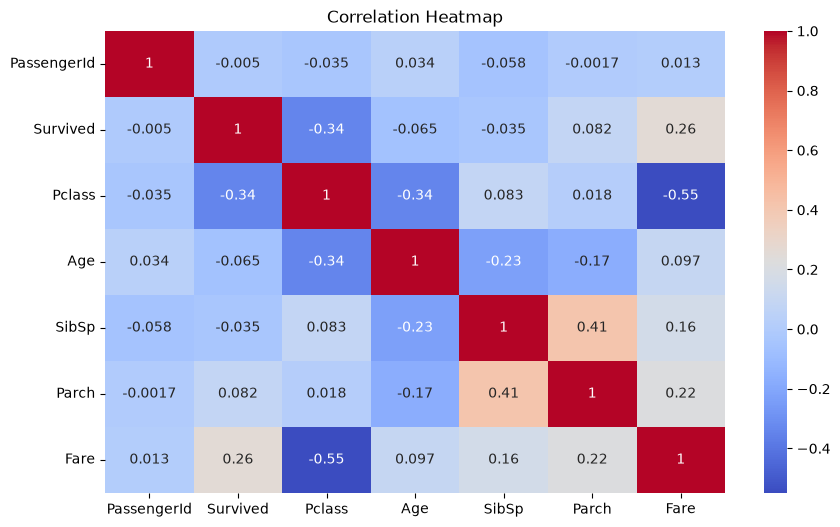

In [82]:
plt.figure(figsize=(10,6))

numeric_df=df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("../images/heatmap.png")

plt.show()

In [83]:
df.to_csv("../cleaned_data/final_cleaned_titanic.csv",index=False)

print("Project Completed Successfully")

Project Completed Successfully
